This file is just an extension of 1.1.Basic_Querying, but defined with functions in a cleaner way, for future referenece. 

The process is detailed below: 
1. Retrieve the data using vizier
2. Cross-reference data using Plate, Fiber, MJD while at the same time retrieving Ftot, zphot, etc.
3. filter table for null values to prevent posterior issues
4. Create new columns for modified parameters (e.g. luminosity from flux and redshift)
5. Plot parameters according to best fit (polynomial and GEMINI)

In [1]:
from astroquery.vizier import Vizier

'''
Vizier links below (to consult variables): 
https://vizier.cds.unistra.fr/viz-bin/VizieR-3?-source=J/ApJ/859/11/gswlc-m2
https://vizier.cds.unistra.fr/viz-bin/VizieR?-source=J/A+A/678/A151
'''

row_lim = 10e4 #10e5 # 5 * 10e3
vizier_custom = Vizier(row_limit=-1, timeout=1000)

def lotss_func():
    lotss_filename = "J/A+A/678/A151"
    viz_lotss = Vizier(columns=['PlateSDSS', 'FiberSDSS', 'MJDSDSS', 'Ftot', 'zphot', 'logMass'], row_limit=row_lim)
    viz_lotss.column_filters = {
        "PlateSDSS": ">0",
        "FiberSDSS": ">0",
        "MJDSDSS": ">0"
    } # non-empty plates, etc.
    lotss_data = viz_lotss.get_catalogs(lotss_filename) 
    return lotss_data[0]

def WISE_func():
    viz_WISE = Vizier(columns=['Plate', 'Fiber', 'MJD', 'logSFR'], row_limit=row_lim)
    viz_WISE.column_filters = {
        "Plate": ">0",
        "Fiber": ">0",
        "MJD": ">0"
    } # non-empty plates, etc. 
    WISE_filename = "J/ApJ/859/11"
    WISE_data = viz_WISE.get_catalogs(WISE_filename) 

    # preparing for merge later
    WISE_data[1].rename_column('Plate', 'PlateSDSS')
    WISE_data[1].rename_column('MJD', 'MJDSDSS')
    WISE_data[1].rename_column('Fiber', 'FiberSDSS')
    
    return WISE_data[1] # getting the Medium HDU

In [2]:
from astropy.table import join
import warnings
from astropy.utils.metadata import MergeConflictWarning

def make_table():
    WISE = WISE_func()
    LOTSS = lotss_func()
    
    warnings.filterwarnings('ignore', category=MergeConflictWarning)
    matched_table = join(LOTSS, WISE, keys=['PlateSDSS', 'MJDSDSS', 'FiberSDSS'], join_type='inner')
    
    print(f"Total sources in LoTSS: {len(LOTSS)}")
    print(f"Total sources in GSWLC-2: {len(WISE)}")
    print(f"Successfully matched sources: {len(matched_table)}")

    return matched_table

In [3]:
import numpy as np

def create_filtered_table():
    matched_table = make_table()
        
    # 1. Filter out masked values (VizieR's default for missing data) and NaNs 
    # The '~' symbol means 'NOT', so we want rows that are NOT masked

    is_valid = ~matched_table['logSFR'].mask & ~matched_table['logMass'].mask
    is_not_nan = ~np.isnan(matched_table['logSFR']) & ~np.isnan(matched_table['logMass'])
    clean_table = matched_table[is_valid & is_not_nan]
    
    print(f"Rows remaining after null-filtering: {len(clean_table)}")
    return clean_table

To convert from flux to luminosity, we need: $$L_{144} = 4 \pi D_L^2  S_{144 MHz}(1+z)^{-1(1+\alpha)}$$

In [4]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

clean_table = create_filtered_table()
cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
z = clean_table['zphot'].filled(np.nan) 
dist_m = cosmo.luminosity_distance(z).to(u.cm).value

alpha = -0.7
k_corr = (1 + z)**(alpha - 1)
flux_w_m2_hz = clean_table['Ftot'] * 1e-29
luminosity = 4 * np.pi * (dist_m**2) * flux_w_m2_hz * k_corr
clean_table['logL144'] = np.log10(luminosity)

print(f"Sample logL144 values: {clean_table['logL144'][:5]}")

Total sources in LoTSS: 100000
Total sources in GSWLC-2: 100000
Successfully matched sources: 4829
Rows remaining after null-filtering: 2867
Sample logL144 values:          logL144         
           mJy           
-------------------------
   26.7575861491712174711
   26.2828205706971473887
   26.9230420655540036989
   26.8735055043872321789
   26.6679793723326561405


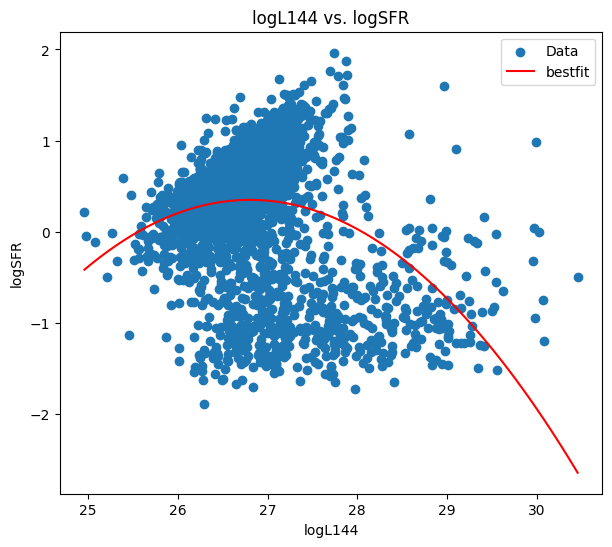

In [5]:
import matplotlib.pyplot as plt

#function to plot two parameters (in clean_table)
def plot(p1, p2): # p1, p2 must be STRINGS!
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(clean_table[p1], clean_table[p2], label = 'Data')

    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    x = clean_table[p1][mask]
    coeff =  np.polyfit(x, clean_table[p2][mask], deg=2)

    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = coeff[0] * x_smooth**2 + coeff[1] * x_smooth + coeff[2]
    ax.plot(x_smooth, y_smooth, label = "bestfit", color = 'r')

    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(p1 + " vs. " + p2)
    plt.legend()
    plt.show()
    
plot("logL144", "logSFR")#, "logMass")

/home/carles-fonseca-mauri/my_jupyter_project/myenv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/carles-fonseca-mauri/my_jupyter_project/myenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


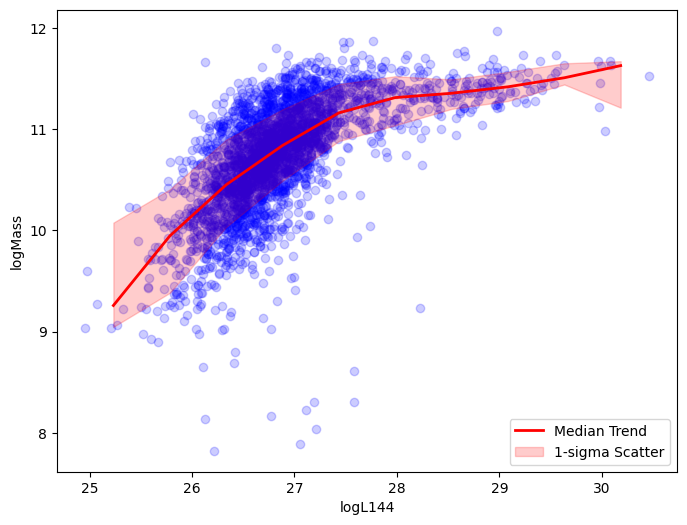

In [14]:
#GEMINI fit best model (use to prevent any bias - such as polynomial fitting)

def plot_binned_trend(p1, p2, bins=10):
    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    x = clean_table[p1][mask]
    y = clean_table[p2][mask]

    # Create bins across the x-axis (Luminosity)
    bin_edges = np.linspace(x.min(), x.max(), bins+1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    lower_error = []
    upper_error = []

    for i in range(bins):
        # Identify points in this luminosity bin
        in_bin = (x >= bin_edges[i]) & (x < bin_edges[i+1])
        if np.any(in_bin):
            medians.append(np.median(y[in_bin]))
            # 16th and 84th percentiles represent a 1-sigma spread
            lower_error.append(np.percentile(y[in_bin], 16))
            upper_error.append(np.percentile(y[in_bin], 84))
        else:
            medians.append(np.nan)
            lower_error.append(np.nan)
            upper_error.append(np.nan)

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.2, color='blue')
    plt.plot(bin_centers, medians, 'r-', lw=2, label='Median Trend')
    plt.fill_between(bin_centers, lower_error, upper_error, color='red', alpha=0.2, label='1-sigma Scatter')
    
    plt.xlabel(p1)
    plt.ylabel(p2)
    plt.legend()
    plt.show()
plot_binned_trend("logL144", "logMass")

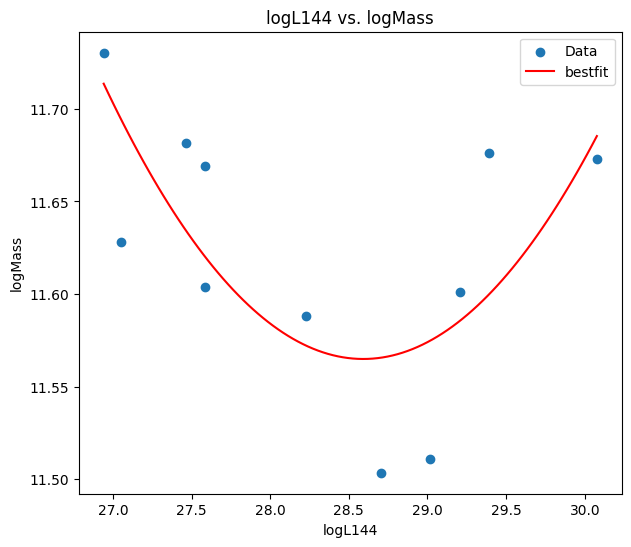

In [15]:
# CHECK FOR DIFFERENT REDSHIFTS (only do when row_lim = 10e5 --> else, insufficient points)
import matplotlib.pyplot as plt

#function to plot two parameters (in clean_table)
def plot(p1, p2): # p1, p2 must be STRINGS!
    fig, ax = plt.subplots(figsize=(7, 6))
    
    m2 = np.where((clean_table['zphot']>0.3) &
                  (clean_table['zphot']<0.8))
    ax.scatter(clean_table[p1][m2], clean_table[p2][m2], label = 'Data')

    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    x = clean_table[p1][mask][m2]
    coeff =  np.polyfit(x, clean_table[p2][mask][m2], deg=2)

    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = coeff[0] * x_smooth**2 + coeff[1] * x_smooth + coeff[2]
    ax.plot(x_smooth, y_smooth, label = "bestfit", color = 'r')

    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(p1 + " vs. " + p2)
    plt.legend()
    plt.show()
    
plot("logL144", "logMass")

This plot tells us very clearly that most of the samples are below z = 0.3

Also, we infer that higher masses come from higher redshifts (as expected --> older galaxies), but also to higher SMBH power (x-axis). 